# Витрина визуализаций: Juventus — Lazio 2:2 (Serie A, 08.02.2026)

Тестовый ноутбук: что можно построить поверх слоя **gold** платформы одними `pandas` +
`matplotlib` (без mplsoccer и прочих футбольных библиотек). Данные читаются из Trino:

| Что | Таблица gold | Источник |
|---|---|---|
| События с координатами (SPADL, поле 0–100 × 0–100, атака слева направо) | `fct_event` | WhoScored |
| Удары с xG | `fct_shot` | Understat |
| Командная статистика по матчам | `fct_team_match` | FotMob / FBref |
| Статистика игроков по матчам | `fct_player_match` | FotMob / FBref |
| Справочники | `dim_match`, `dim_team`, `dim_player` | — |

Матч выбран как показательный: Juventus владел мячом 63 %, нанёс 34 удара на 2,86 xG,
но сыграл 2:2 с Lazio (9 ударов, 0,81 xG).

Графики:
1. Потери в своей трети и какие из них привели к удару соперника
2. Изменение формы команд лиги: последние 7 туров против начала сезона
3. Кумулятивный xG матча и территориальный «моментум»
4. Карта передач игрока и его перцентили по лиге
5. Удары и входы в 20-метровую зону у ворот
6. Сеть передач

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import trino
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Ellipse, Arc, FancyArrowPatch

warnings.filterwarnings("ignore")

# В JupyterHub платформы переменные TRINO_* уже в окружении (docs/ANALYST_ONBOARDING.md).
# TRINO_VERIFY=false — только для локального запуска с самоподписанным сертификатом.
_conn = trino.dbapi.connect(
    host=os.environ.get("TRINO_HOST", "trino"),
    port=int(os.environ.get("TRINO_PORT", "443")),
    user=os.environ.get("TRINO_USER", "analyst_svc"),
    http_scheme="https",
    auth=trino.auth.BasicAuthentication(
        os.environ.get("TRINO_USER", "analyst_svc"), os.environ["TRINO_PASSWORD"]
    ),
    verify=os.environ.get("TRINO_VERIFY", "true").lower() != "false",
    catalog="iceberg",
    schema="gold",
)


def q(sql: str) -> pd.DataFrame:
    cur = _conn.cursor()
    cur.execute(sql)
    return pd.DataFrame(cur.fetchall(), columns=[c[0] for c in cur.description])


MATCH_ID = "83708428"
LEAGUE, SEASON = "ITA-Serie A", "2526"

## Стиль и поле

Тёмная тема и поле, нарисованное вручную в единицах WhoScored (0–100), с пропорциями 105 × 68 м.

In [2]:
BG, PANEL, LINE, TEXT, MUTED = "#0f1218", "#161b24", "#6b7386", "#e8eaf0", "#8d95a8"
OK, BAD, GOLD = "#2dd4bf", "#f87171", "#fbbf24"
TEAM_COLORS = {"juventus": "#f5f5f5", "lazio": "#7dd3fc"}

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "axes.edgecolor": LINE, "axes.labelcolor": TEXT, "text.color": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": "#2a3140",
    "font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "legend.frameon": False,
    "figure.dpi": 110,
})

PITCH_L, PITCH_W = 105.0, 68.0  # метры


def to_m(x, y):
    # 0–100 → метры
    return np.asarray(x) * PITCH_L / 100, np.asarray(y) * PITCH_W / 100


def dist_to_goal_m(x, y):
    xm, ym = to_m(x, y)
    return np.hypot(PITCH_L - xm, PITCH_W / 2 - ym)


def draw_pitch(ax, lc=LINE, lw=1.0):
    # Всё в единицах 0–100; aspect подгоняет вид под 105×68
    kx, ky = 100 / PITCH_L, 100 / PITCH_W
    ax.add_patch(Rectangle((0, 0), 100, 100, fill=False, ec=lc, lw=lw))
    ax.plot([50, 50], [0, 100], color=lc, lw=lw)
    for x0, sign in ((0, 1), (100, -1)):
        ax.add_patch(Rectangle((x0 if sign > 0 else x0 - 16.5 * kx, 50 - 20.16 * ky),
                               16.5 * kx, 40.32 * ky, fill=False, ec=lc, lw=lw))
        ax.add_patch(Rectangle((x0 if sign > 0 else x0 - 5.5 * kx, 50 - 9.16 * ky),
                               5.5 * kx, 18.32 * ky, fill=False, ec=lc, lw=lw))
        ax.add_patch(Rectangle((x0 - 2 if sign > 0 else x0, 50 - 3.66 * ky),
                               2, 7.32 * ky, fill=False, ec=lc, lw=lw))  # ворота
        px = x0 + sign * 11 * kx
        ax.plot(px, 50, ".", color=lc, ms=3)
        ax.add_patch(Arc((px, 50), 2 * 9.15 * kx, 2 * 9.15 * ky,
                         theta1=-53 if sign > 0 else 127, theta2=53 if sign > 0 else 233,
                         color=lc, lw=lw))
    ax.add_patch(Ellipse((50, 50), 2 * 9.15 * kx, 2 * 9.15 * ky, fill=False, ec=lc, lw=lw))
    ax.plot(50, 50, ".", color=lc, ms=3)
    ax.set_xlim(-3, 103)
    ax.set_ylim(-3, 103)
    ax.set_aspect(PITCH_W / PITCH_L)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    return ax


def arrow(ax, x0, y0, x1, y1, color, lw=1.2, alpha=0.9, ms=8):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=ms,
                                 color=color, lw=lw, alpha=alpha, shrinkA=0, shrinkB=0))


def caption(fig, text):
    fig.text(0.01, 0.005, text, color=MUTED, fontsize=8, ha="left", va="bottom")

## Данные матча

In [3]:
match = q(f'''
SELECT m.match_id, m.match_date, m.league, m.season, m.gameweek,
       m.home_team_id, h.team_name AS home_name, m.home_score,
       m.away_team_id, a.team_name AS away_name, m.away_score
FROM dim_match m
JOIN dim_team h ON h.team_id = m.home_team_id
JOIN dim_team a ON a.team_id = m.away_team_id
WHERE m.match_id = '{MATCH_ID}'
''').iloc[0]
HOME, AWAY = match.home_team_id, match.away_team_id
NAMES = {HOME: match.home_name, AWAY: match.away_name}
TITLE = f"{match.home_name} {match.home_score}–{match.away_score} {match.away_name} · Serie A · {match.match_date:%d.%m.%Y}"

events = q(f'''
SELECT event_id, team_id, player_id, period, minute, x, y, end_x, end_y,
       action, _action_source_note AS note, outcome_success AS success
FROM fct_event
WHERE match_id = '{MATCH_ID}' AND period IN ('FirstHalf', 'SecondHalf')
ORDER BY event_id
''').reset_index(drop=True)
events["seq"] = np.arange(len(events))

shots = q(f'''
SELECT s.team_id, s.player_id, p.player_name, s.minute, s.x * 100 AS x, s.y * 100 AS y,
       s.xg, s.situation, s.result, s.is_goal
FROM fct_shot s LEFT JOIN dim_player p ON p.player_id = s.player_id
WHERE s.match_id = '{MATCH_ID}'
ORDER BY s.minute
''')

players = q(f'''
SELECT p.player_id, d.player_name, p.team_id, p.minutes_played, p.passes, p.passes_completed,
       p.key_passes, p.xa, p.xg_chain, p.xg_buildup
FROM fct_player_match p LEFT JOIN dim_player d ON d.player_id = p.player_id
WHERE p.match_id = '{MATCH_ID}'
''')
print(TITLE)
print(f"событий: {len(events)}, ударов: {len(shots)}, игроков: {len(players)}")
shots.groupby("team_id").agg(shots=("xg", "size"), xg=("xg", "sum"), goals=("is_goal", "sum")).round(2)

Juventus 2–2 Lazio · Serie A · 08.02.2026
событий: 1713, ударов: 43, игроков: 32


,shots,xg,goals
team_id,,,
juventus,34,2.86,2
lazio,9,0.81,2


## 1. Потери в своей трети

Потеря — неудачная передача/кросс/ввод, неудачный обыгрыш или `bad_touch` (плохая обработка,
отбор соперника, ошибка) на своих 40 % поля. Звезда — в следующих 10 действиях соперник нанёс удар.

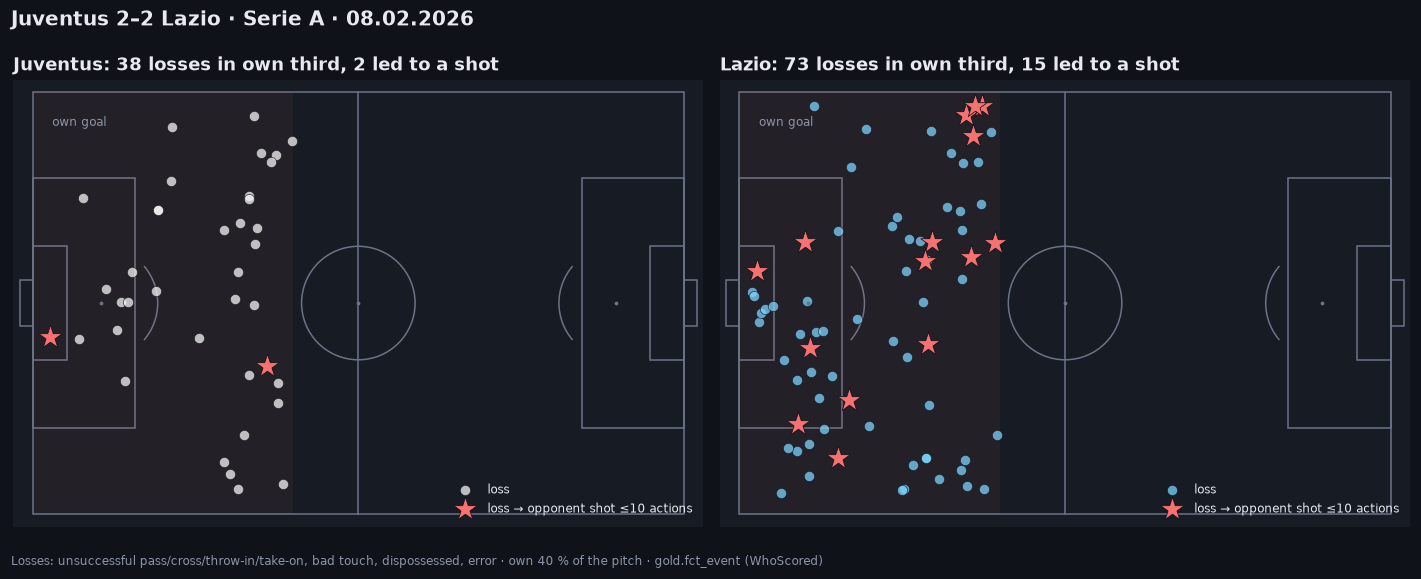

In [4]:
LOSS_PASS = {"pass", "cross", "throw_in", "goalkick", "freekick_short", "freekick_crossed",
             "corner_short", "corner_crossed"}
is_loss = (
    events.action.eq("bad_touch")
    | (events.action.isin(LOSS_PASS) & ~events.success.fillna(True))
    | (events.action.eq("take_on") & ~events.success.fillna(True))
)
losses = events[is_loss & (events.x <= 40)].copy()

shot_idx = events.index[events.action.isin(["shot", "shot_freekick"])]
def led_to_shot(row, window=10):
    nxt = events.iloc[row.seq + 1 : row.seq + 1 + window]
    nxt = nxt[nxt.period == row.period]
    return bool(((nxt.team_id != row.team_id) & nxt.action.isin(["shot", "shot_freekick"])).any())
losses["led_to_shot"] = losses.apply(led_to_shot, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, team in zip(axes, (HOME, AWAY)):
    draw_pitch(ax)
    ax.add_patch(Rectangle((0, 0), 40, 100, fc=BAD, alpha=0.06, ec="none"))
    d = losses[losses.team_id == team]
    plain, star = d[~d.led_to_shot], d[d.led_to_shot]
    ax.scatter(plain.x, plain.y, s=45, c=TEAM_COLORS[team], alpha=0.75, ec=BG, lw=0.5,
               label="loss")
    ax.scatter(star.x, star.y, s=260, marker="*", c=BAD, ec=BG, lw=0.5,
               label="loss → opponent shot ≤10 actions")
    ax.set_title(f"{NAMES[team]}: {len(d)} losses in own third, {len(star)} led to a shot")
    ax.annotate("own goal", (0.5, 50), xytext=(3, 92), color=MUTED, fontsize=8)
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle(TITLE, x=0.01, ha="left", fontsize=13, fontweight="bold")
caption(fig, "Losses: unsuccessful pass/cross/throw-in/take-on, bad touch, dispossessed, error · own 40 % of the pitch · gold.fct_event (WhoScored)")
plt.tight_layout()

## 2. Изменение формы: последние 7 туров против всего сезона до них

Каждая стрелка — команда Serie A 2025/26: хвост — средние за игру по турам с 1-го по 31-й,
голова — по последним 7 турам. По осям — xG с игры (open play) за и против, из ударов Understat.
Правый верхний угол — лучше.

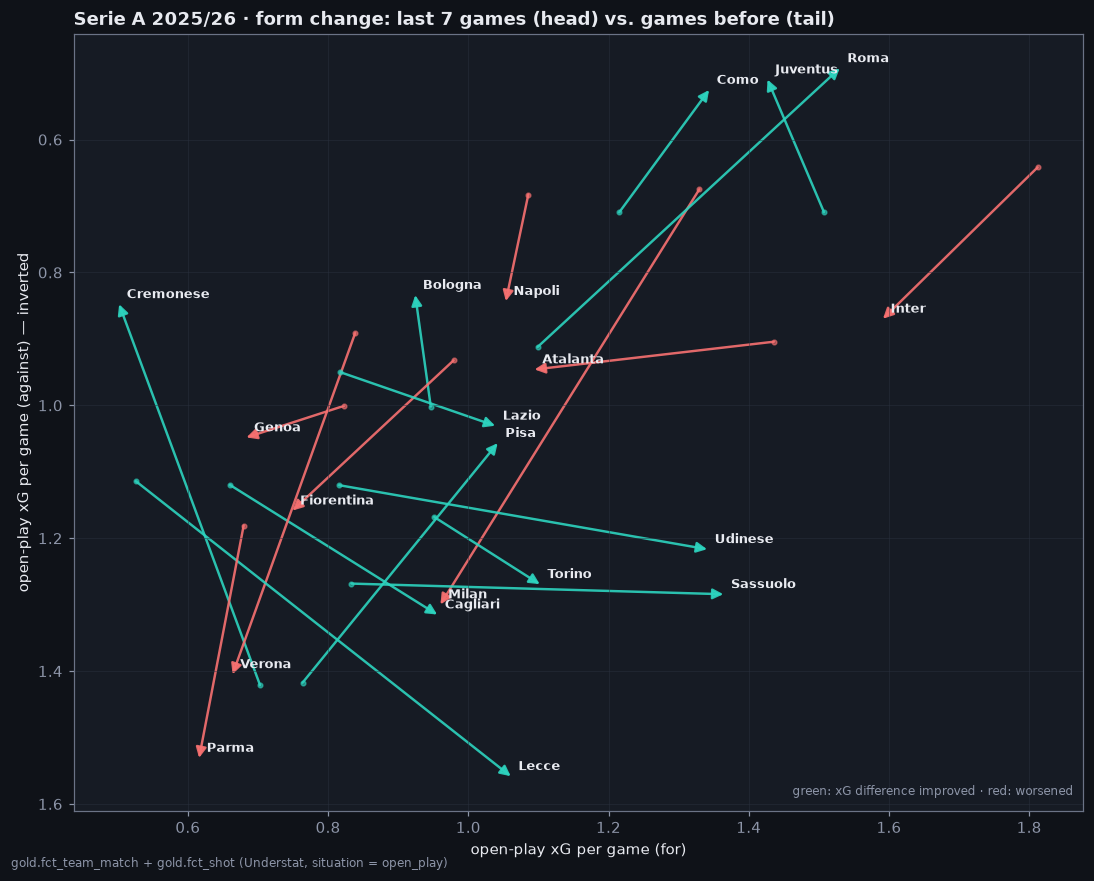

In [5]:
team_matches = q(f'''
WITH sx AS (
  SELECT match_id, team_id,
         sum(CASE WHEN situation = 'open_play' THEN xg ELSE 0 END) AS op_xg
  FROM fct_shot WHERE league = '{LEAGUE}' AND season = '{SEASON}' GROUP BY 1, 2
)
SELECT t.team_id, d.short_name, t.date, t.gameweek, t.opponent_id,
       t.xg, t.xga, t.ppda, t.possession_pct, t.deep_completions,
       coalesce(f.op_xg, 0) AS op_xg_for, coalesce(a.op_xg, 0) AS op_xg_against
FROM fct_team_match t
JOIN dim_team d ON d.team_id = t.team_id
LEFT JOIN sx f ON f.match_id = t.match_id AND f.team_id = t.team_id
LEFT JOIN sx a ON a.match_id = t.match_id AND a.team_id = t.opponent_id
WHERE t.league = '{LEAGUE}' AND t.season = '{SEASON}' AND t.is_completed
ORDER BY t.team_id, t.date
''')
LAST_N = 7
team_matches["is_recent"] = team_matches.groupby("team_id").cumcount(ascending=False) < LAST_N
form = (team_matches.groupby(["team_id", "short_name", "is_recent"])[["op_xg_for", "op_xg_against"]]
        .mean().unstack("is_recent"))

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True, lw=0.5, alpha=0.6)
for (team, name), row in form.iterrows():
    x0, y0 = row[("op_xg_for", False)], row[("op_xg_against", False)]
    x1, y1 = row[("op_xg_for", True)], row[("op_xg_against", True)]
    better = (x1 - y1) > (x0 - y0)
    c = OK if better else BAD
    arrow(ax, x0, y0, x1, y1, c, lw=1.6, ms=14, alpha=0.9)
    ax.plot(x0, y0, "o", color=c, ms=3, alpha=0.6)
    ax.annotate(name, (x1, y1), xytext=(5, 4), textcoords="offset points",
                fontsize=8.5, color=TEXT, fontweight="bold")
ax.invert_yaxis()
ax.set_xlabel("open-play xG per game (for)")
ax.set_ylabel("open-play xG per game (against) — inverted")
ax.set_title(f"Serie A 2025/26 · form change: last {LAST_N} games (head) vs. games before (tail)")
ax.text(0.99, 0.02, "green: xG difference improved · red: worsened",
        transform=ax.transAxes, ha="right", color=MUTED, fontsize=8)
caption(fig, "gold.fct_team_match + gold.fct_shot (Understat, situation = open_play)")
plt.tight_layout()

## 3. Кумулятивный xG и территориальный моментум

Сверху — накопленный xG обеих команд по минутам, голы подписаны. Снизу — доля действий каждой
команды в финальной трети соперника по 5-минутным отрезкам: вверх — давление хозяев, вниз — гостей.

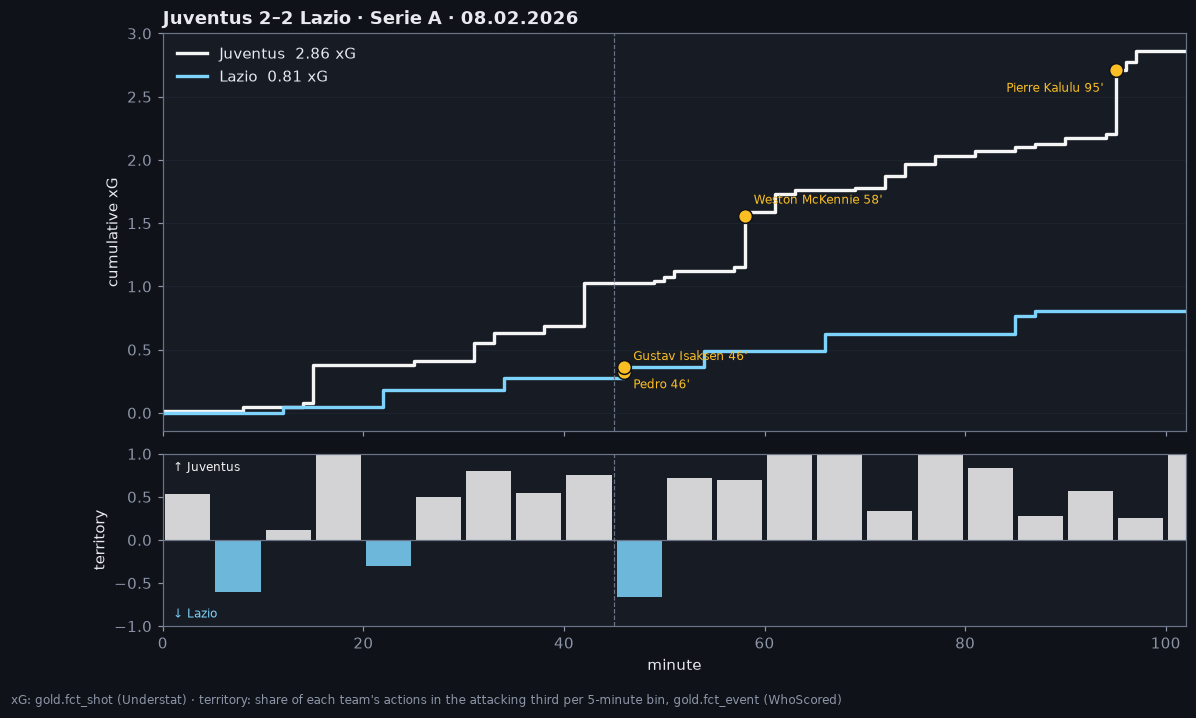

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.3], "hspace": 0.08})
max_min = int(max(events.minute.max(), shots.minute.max())) + 1
for team in (HOME, AWAY):
    s = shots[shots.team_id == team].sort_values("minute")
    minutes = np.concatenate([[0], s.minute.values, [max_min]])
    cum = np.concatenate([[0], s.xg.cumsum().values, [s.xg.sum()]])
    ax1.step(minutes, cum, where="post", color=TEAM_COLORS[team], lw=2.2,
             label=f"{NAMES[team]}  {s.xg.sum():.2f} xG")
    g = s[s.is_goal]
    for i, (_, r) in enumerate(g.iterrows()):
        yv = s.loc[: r.name, "xg"].sum()
        ax1.plot(r.minute, yv, "o", ms=9, mfc=GOLD, mec=BG)
        late = r.minute > max_min - 15
        ax1.annotate(f"{r.player_name} {int(r.minute)}'", (r.minute, yv),
                     xytext=(-8 if late else 6, -14 if i % 2 else 8), ha="right" if late else "left",
                     textcoords="offset points", fontsize=8, color=GOLD)
ax1.axvline(45, color=LINE, lw=0.8, ls="--")
ax1.set_ylabel("cumulative xG")
ax1.legend(loc="upper left")
ax1.set_title(TITLE)
ax1.grid(True, axis="y", lw=0.5, alpha=0.5)

BIN = 5
ev = events[events.action.ne("unknown") & events.player_id.ne("")].copy()
ev["bin"] = (ev.minute // BIN) * BIN
ft = ev[ev.x >= 200 / 3].groupby(["bin", "team_id"]).size().unstack(fill_value=0)
ft = ft.reindex(range(0, max_min + BIN, BIN), fill_value=0)
tilt = (ft.get(HOME, 0) - ft.get(AWAY, 0)) / (ft.get(HOME, 0) + ft.get(AWAY, 0)).replace(0, np.nan)
colors = [TEAM_COLORS[HOME] if v >= 0 else TEAM_COLORS[AWAY] for v in tilt.fillna(0)]
ax2.bar(tilt.index + BIN / 2, tilt.fillna(0), width=BIN * 0.9, color=colors, alpha=0.85)
ax2.axhline(0, color=LINE, lw=0.8)
ax2.axvline(45, color=LINE, lw=0.8, ls="--")
ax2.set_ylim(-1, 1)
ax2.set_ylabel("territory")
ax2.set_xlabel("minute")
ax2.set_xlim(0, max_min)
ax2.text(0.01, 0.9, f"↑ {NAMES[HOME]}", transform=ax2.transAxes, fontsize=8, color=TEAM_COLORS[HOME])
ax2.text(0.01, 0.05, f"↓ {NAMES[AWAY]}", transform=ax2.transAxes, fontsize=8, color=TEAM_COLORS[AWAY])
caption(fig, f"xG: gold.fct_shot (Understat) · territory: share of each team's actions in the attacking third per {BIN}-minute bin, gold.fct_event (WhoScored)")

## 4. Карта передач игрока и перцентили по лиге

Игрок — лучший по числу передач в матче. Справа — его показатели за сезон 2025/26 (на 90 минут)
против всех игроков Serie A с ≥ 900 минут: точка — перцентиль.

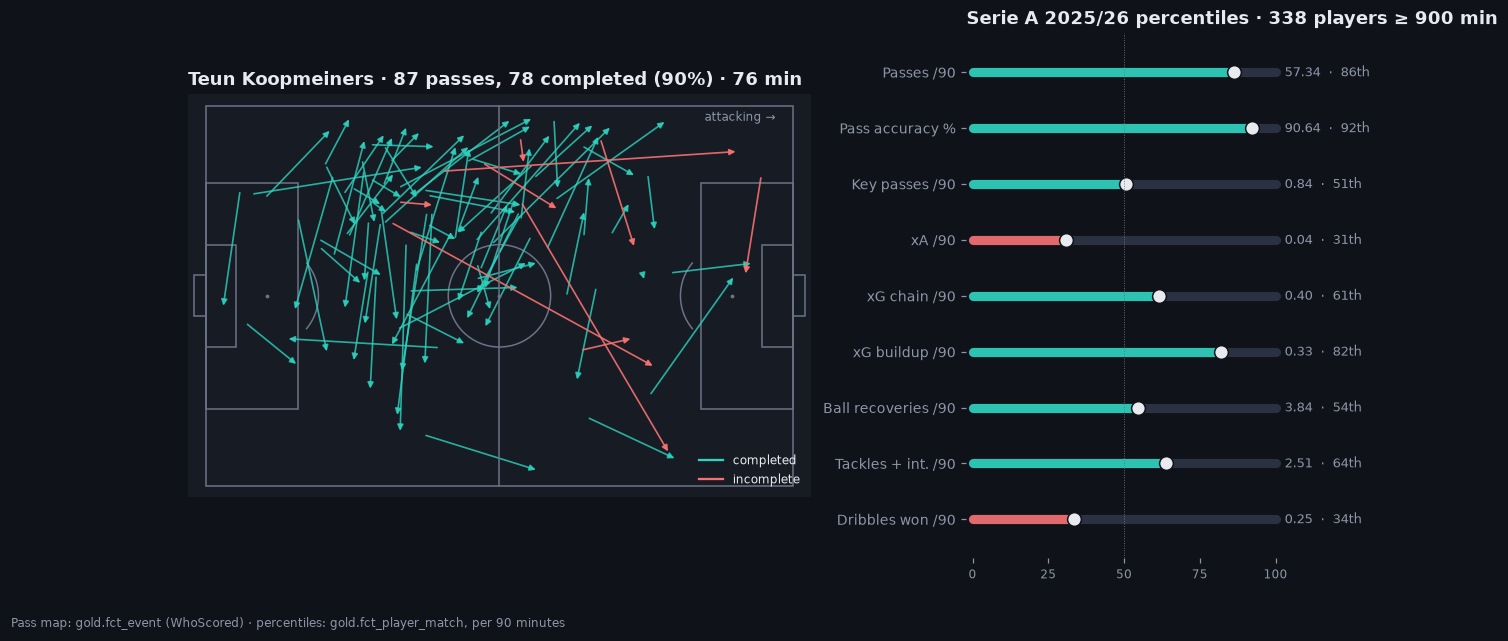

In [7]:
top = players[players.team_id == HOME].sort_values("passes", ascending=False).iloc[0]
PLAYER_ID, PLAYER = top.player_id, top.player_name

season_players = q(f'''
SELECT p.player_id, d.player_name, sum(minutes_played) AS minutes,
       sum(passes) AS passes, sum(passes_completed) AS passes_completed,
       sum(key_passes) AS key_passes, sum(xa) AS xa, sum(xg_chain) AS xg_chain,
       sum(xg_buildup) AS xg_buildup, sum(ball_recoveries) AS ball_recoveries,
       sum(tackles) + sum(interceptions) AS tackles_int, sum(dribbles_won) AS dribbles_won
FROM fct_player_match p LEFT JOIN dim_player d ON d.player_id = p.player_id
WHERE p.league = '{LEAGUE}' AND p.season = '{SEASON}'
GROUP BY 1, 2 HAVING sum(minutes_played) >= 900
''')
def per90(col):
    return season_players[col] / season_players.minutes * 90


metrics = pd.DataFrame({
    "Passes /90": per90("passes"),
    "Pass accuracy %": season_players.passes_completed / season_players.passes * 100,
    "Key passes /90": per90("key_passes"),
    "xA /90": per90("xa"),
    "xG chain /90": per90("xg_chain"),
    "xG buildup /90": per90("xg_buildup"),
    "Ball recoveries /90": per90("ball_recoveries"),
    "Tackles + int. /90": per90("tackles_int"),
    "Dribbles won /90": per90("dribbles_won"),
})
metrics.index = season_players.player_id
pct = metrics.rank(pct=True) * 100
assert PLAYER_ID in metrics.index, "игрока нет в сезонной выборке (мало минут?)"

passes = events[(events.player_id == PLAYER_ID) & events.action.isin(["pass", "cross"])]

fig = plt.figure(figsize=(14, 6.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.3)
ax = fig.add_subplot(gs[0])
draw_pitch(ax)
for ok, color in ((True, OK), (False, BAD)):
    d = passes[passes.success.fillna(False) == ok]
    for _, r in d.iterrows():
        arrow(ax, r.x, r.y, r.end_x, r.end_y, color, lw=1.1, alpha=0.8 if ok else 0.9)
n_ok = int(passes.success.fillna(False).sum())
ax.set_title(f"{PLAYER} · {len(passes)} passes, {n_ok} completed ({n_ok / max(len(passes), 1):.0%}) · {int(top.minutes_played)} min")
ax.plot([], [], color=OK, label="completed")
ax.plot([], [], color=BAD, label="incomplete")
ax.legend(loc="lower right", fontsize=8)
ax.annotate("attacking →", (97, 96), ha="right", color=MUTED, fontsize=8)

ax2 = fig.add_subplot(gs[1])
labels = list(metrics.columns)[::-1]
for i, m in enumerate(labels):
    p, v = pct.loc[PLAYER_ID, m], metrics.loc[PLAYER_ID, m]
    ax2.plot([0, 100], [i, i], color="#2a3140", lw=6, solid_capstyle="round")
    ax2.plot([0, p], [i, i], color=OK if p >= 50 else BAD, lw=6, solid_capstyle="round", alpha=0.9)
    ax2.plot(p, i, "o", ms=9, mfc=TEXT, mec=BG)
    ax2.text(103, i, f"{v:.2f}  ·  {p:.0f}th", va="center", fontsize=8.5, color=MUTED)
ax2.set_yticks(range(len(labels)))
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlim(-2, 135)
ax2.set_ylim(-0.7, len(labels) - 0.3)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.tick_params(axis="x", labelsize=8)
ax2.axvline(50, color=LINE, lw=0.6, ls=":")
for s in ax2.spines.values():
    s.set_visible(False)
ax2.set_facecolor(BG)
ax2.set_title(f"Serie A 2025/26 percentiles · {len(metrics)} players ≥ 900 min")
caption(fig, "Pass map: gold.fct_event (WhoScored) · percentiles: gold.fct_player_match, per 90 minutes")

## 5. Удары и входы в зону 20 м от ворот

Круги — удары (размер по xG, золотая звезда — гол). Стрелки — передачи и кроссы, которые
завершились в 20 метрах от центра ворот, начавшись за её пределами (входы в опасную зону).

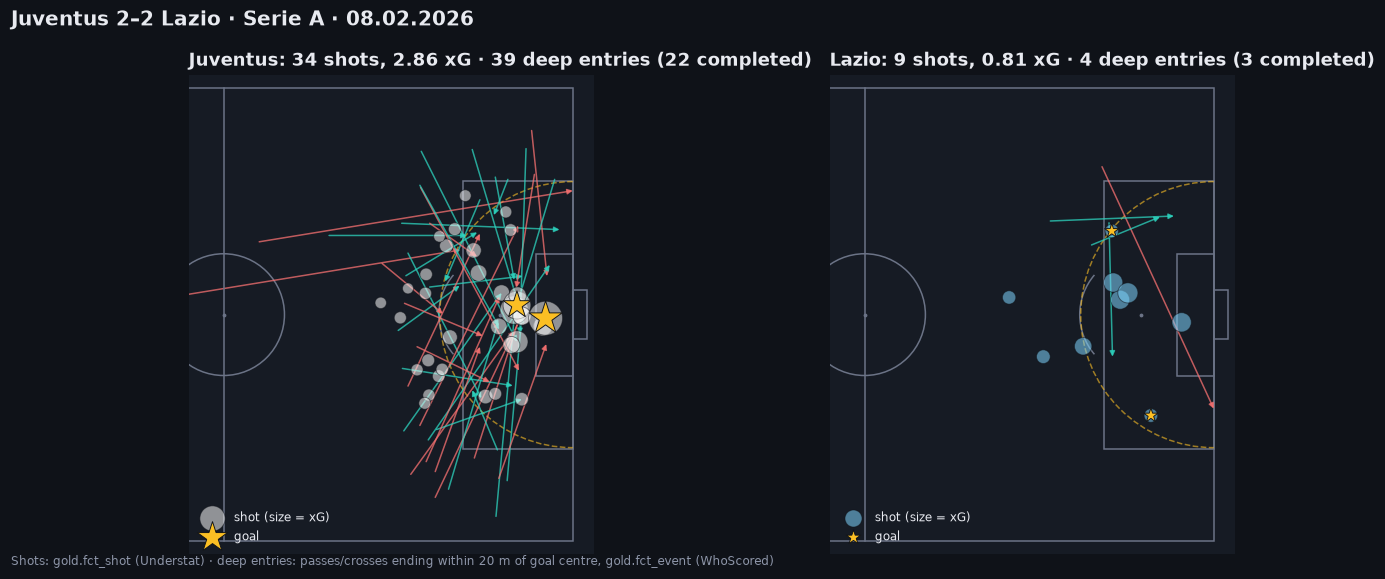

In [8]:
DEEP_M = 20
kx, ky = 100 / PITCH_L, 100 / PITCH_W
entries = events[events.action.isin(["pass", "cross"]) & events.end_x.notna()].copy()
entries = entries[(dist_to_goal_m(entries.end_x, entries.end_y) <= DEEP_M)
                  & (dist_to_goal_m(entries.x, entries.y) > DEEP_M)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, team in zip(axes, (HOME, AWAY)):
    draw_pitch(ax)
    ax.add_patch(Arc((100, 50), 2 * DEEP_M * kx, 2 * DEEP_M * ky, theta1=90, theta2=270,
                     color=GOLD, lw=1, ls="--", alpha=0.6))
    e = entries[entries.team_id == team]
    for _, r in e.iterrows():
        arrow(ax, r.x, r.y, r.end_x, r.end_y, OK if r.success else BAD, lw=1.0, alpha=0.75, ms=7)
    s = shots[shots.team_id == team]
    ax.scatter(s.x, s.y, s=40 + s.xg * 900, c=TEAM_COLORS[team], alpha=0.55, ec=BG, lw=0.6,
               label="shot (size = xG)")
    g = s[s.is_goal]
    ax.scatter(g.x, g.y, s=60 + g.xg * 900, marker="*", c=GOLD, ec=BG, lw=0.6, label="goal", zorder=5)
    n_ok = int(e.success.fillna(False).sum())
    ax.set_title(f"{NAMES[team]}: {len(s)} shots, {s.xg.sum():.2f} xG · {len(e)} deep entries ({n_ok} completed)")
    ax.legend(loc="lower left", fontsize=8)
    ax.set_xlim(45, 103)
fig.suptitle(TITLE, x=0.01, ha="left", fontsize=13, fontweight="bold")
caption(fig, f"Shots: gold.fct_shot (Understat) · deep entries: passes/crosses ending within {DEEP_M} m of goal centre, gold.fct_event (WhoScored)")
plt.tight_layout()

## 6. Сеть передач

Узлы — средняя позиция игрока по всем его действиям (игроки с ≥ 45 минут), размер — число передач.
Связи — успешные передачи между парами (от 3 и больше), толщина по количеству.

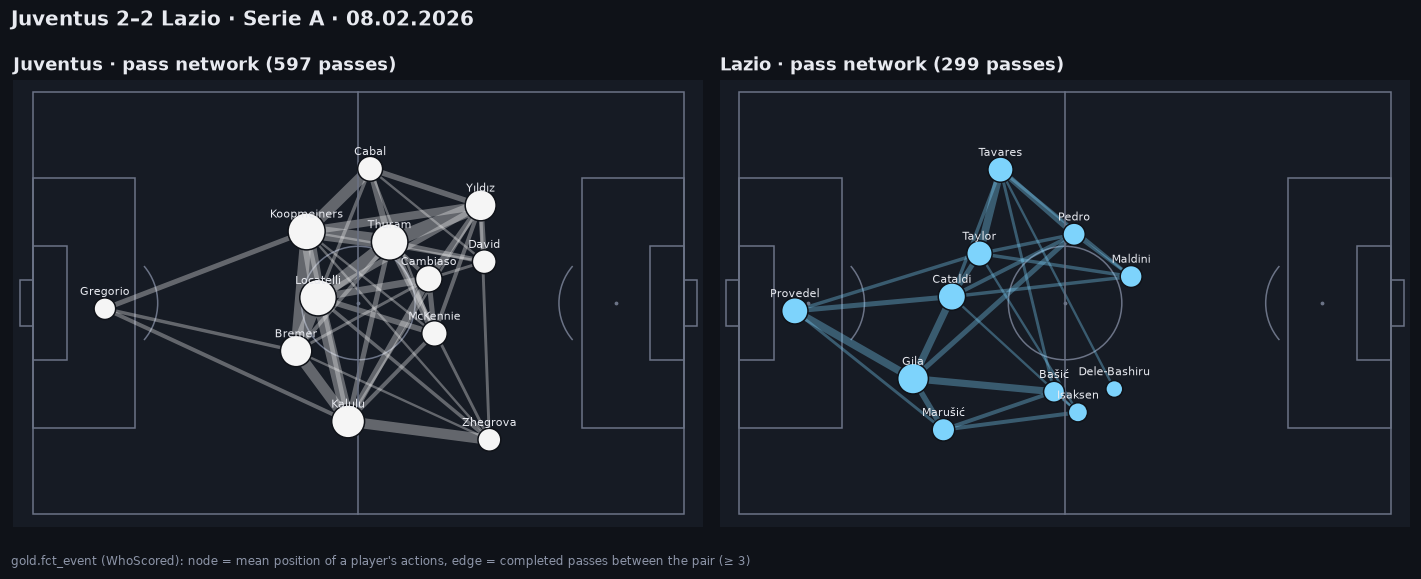

In [9]:
def pass_network(ax, team, min_minutes=45, min_edge=3):
    ev_t = events[(events.team_id == team) & events.player_id.ne("")]
    starters = set(players[(players.team_id == team) & (players.minutes_played >= min_minutes)].player_id)
    pos = ev_t[ev_t.player_id.isin(starters)].groupby("player_id")[["x", "y"]].mean()
    names = players.set_index("player_id").player_name
    # получатель — следующий игрок той же команды с мячом после успешной передачи
    nxt = events.shift(-1)
    ok = ev_t[ev_t.action.isin(["pass"]) & ev_t.success.fillna(False)].index
    edges = pd.DataFrame({"src": events.loc[ok, "player_id"], "dst": nxt.loc[ok, "player_id"],
                          "same": nxt.loc[ok, "team_id"] == team})
    edges = edges[edges.same & edges.dst.ne("") & edges.src.isin(starters) & edges.dst.isin(starters)]
    edges = edges[edges.src != edges.dst].groupby(["src", "dst"]).size()
    edges = edges.groupby(lambda k: tuple(sorted(k))).sum()  # ненаправленно
    n_pass = ev_t[ev_t.action.eq("pass")].groupby("player_id").size().reindex(pos.index, fill_value=0)

    draw_pitch(ax)
    for (a, b), n in edges[edges >= min_edge].items():
        ax.plot([pos.x[a], pos.x[b]], [pos.y[a], pos.y[b]], color=TEAM_COLORS[team],
                lw=0.5 + n * 0.35, alpha=0.35, solid_capstyle="round", zorder=1)
    ax.scatter(pos.x, pos.y, s=80 + n_pass * 6, c=TEAM_COLORS[team], ec=BG, lw=1, zorder=3)
    for pid, r in pos.iterrows():
        ax.annotate(names.get(pid, pid).split()[-1], (r.x, r.y), xytext=(0, 9),
                    textcoords="offset points", ha="center", fontsize=7.5, color=TEXT, zorder=4)
    ax.set_title(f"{NAMES[team]} · pass network ({int(n_pass.sum())} passes)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, team in zip(axes, (HOME, AWAY)):
    pass_network(ax, team)
fig.suptitle(TITLE, x=0.01, ha="left", fontsize=13, fontweight="bold")
caption(fig, "gold.fct_event (WhoScored): node = mean position of a player's actions, edge = completed passes between the pair (≥ 3)")
plt.tight_layout()

## Что ещё можно построить на этих же данных

- Карта прессинга и возвратов мяча (`ball_recovery`, `tackle`, `interception`) по зонам.
- Сравнение игроков «радаром» по перцентилям из блока 4.
- Хронология сезона: xG за/против по турам с скользящим средним (`fct_team_match`).
- Тепловая карта касаний игрока и «сонары» передач по направлениям.
- Модель угрозы (xT) поверх `fct_event` — тогда моментум из блока 3 станет «не-ударным xG».